In [1]:
import cartopy.crs as ccrs
import geopandas as gpd
import joblib
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import rasterio
import seaborn as sns
import sincomp.auxiliary
import sincomp.compare
import sincomp.datasets
from sklearn.decomposition import PCA
from sklearn.impute import KNNImputer
from sklearn.pipeline import make_pipeline
import sys

sincomp_root = os.path.join(os.path.expanduser('~'), 'git', 'sincomp')
sys.path.append(os.path.join(sincomp_root, 'scripts'))
from isogloss import isogloss

selenium not installed, to use full functionality, install it with
        pip install selenium
Cannot download zhongguoyuyan automatically without selenium, make sure you have downloaded it manually from https://zhongguoyuyan.cn/ to /home/dad/.local/share/sincomp/datasets/zhongguoyuyan .


In [2]:
plt.rcParams['font.family'] = ['dejavu sans', 'Noto Sans CJK JP']

In [3]:
rules = sincomp.compare.load_rules(os.path.join(sincomp_root, 'data', 'mandarin_rules.json'))
rule_ids = rules.index.to_list()
rule_names = rules['name'].to_list()

display(rules)

,name,feature,cid1,cid2
id,,,,
0,佳開=皆開,final,"[3264, 3368, 3373, 11270, 11277, 11296, 11301,...","[3370, 3404, 16794, 16851, 埋, 戒, 拜, 排, 0134, 0..."
1,佳開=齊開,final,"[3264, 3368, 3373, 11270, 11277, 11296, 11301,...","[2925, 2965, 2990, 2993, 3066, 3130, 3146, 319..."
2,先開=仙開,final,"[5074, 5084, 5108, 5150, 5169, 5190, 5219, 526...","[5297, 18214, 仙, 變, 0497]"
3,咍端=泰開端,final,"[3609, 3612, 3645, 3647, 3648, 3654, 3681, 368...","[16548, 16550, 16585, 16686, 太, 帶, 泰, 賴, 0131]"
16,文開=真開,final,"[3905, 3921, 4273, 4274, 4282, 4283, 11747, 勤,...","[3753, 11551, 17323, 印, 因, 緊, 0641, 0643]"
22,梗開三四入=曾開三入,final,"[23775, 23849, 23860, 23895, 23957, 23981, 240...","[23774, 24217, 24223, 24227, 24255, 24293, 力, ..."
23,梗開三四陽=曾開三陽,final,"[7689, 7694, 7697, 7704, 7909, 7912, 7916, 792...","[8321, 8323, 8336, 19347, 19374, 19389, 冰, 升, ..."
31,歌開=泰開,final,"[6460, 6478, 6554, 6595, 6642, 6744, 6786, 689...","[16550, 16552, 16581, 16585, 16683, 16686, 太, ..."
38,江莊=陽開莊,final,"[725, 765, 樁, 雙, 0778, 0780, 0781]","[7191, 7209, 7215, 7227, 19039, 壯, 牀, 瘡, 裝, 霜,..."


In [4]:
annotations = pd.read_csv(
    os.path.join(sincomp_root, 'data', 'annotations.csv'),
    dtype=str,
    comment='#',
    encoding='utf-8'
)
for dataset, anno in annotations.groupby('dataset', as_index=False):
    annotations.loc[anno.index, 'name'] = sincomp.datasets.get(dataset).dialects.loc[anno['did'], 'name'].values

display(annotations)

,dataset,did,stratefy,group,label,name
0,CCR,027,官话,北京,官话,北京
1,CCR,046,官话,西安,官话,西安
2,CCR,118,吴语,苏州,非官话,蘇州
3,CCR,136,吴语,温州,非官话,溫州
4,CCR,155,吴语,泾县,非官话,涇縣
...,...,...,...,...,...,...
59,zhongguoyuyan,21E62,徽语,歙县,非官话,歙县
60,zhongguoyuyan,24C62,官话,洛阳,官话,洛阳
61,zhongguoyuyan,26509,湘语,双峰,非官话,双峰
62,zhongguoyuyan,26J48,湘语,娄底,非官话,娄底


In [5]:
compliances = []
for dataset, anno in annotations.groupby('dataset', as_index=False):
    data = sincomp.datasets.get(dataset).select(anno['did']).data
    if 'cid' not in data.columns:
        data = data.rename(columns={'character': 'cid'})

    data = sincomp.preprocess.transform(
        data,
        index='cid',
        columns='did',
        values=['initial', 'final', 'tone'],
        aggfunc=lambda s: ' '.join(s.dropna())
    )
    compliances.append(sincomp.compare.compliance(data, rules).set_index(anno.index))

compliances = pd.concat(compliances, axis=0).loc[annotations.index]

/home/dad/git/sincomp/src/sincomp/compare.py:110: RuntimeWarning: invalid value encountered in divide
  x1 /= numpy.linalg.norm(x1, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:111: RuntimeWarning: invalid value encountered in divide
  x2 /= numpy.linalg.norm(x2, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:111: RuntimeWarning: invalid value encountered in divide
  x2 /= numpy.linalg.norm(x2, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:111: RuntimeWarning: invalid value encountered in divide
  x2 /= numpy.linalg.norm(x2, norm, axis=1, keepdims=True)


In [6]:
datasets = []
dids = []
compliances1 = []
compliances2 = []
for dataset in 'CCR', 'MCPDict', 'zhongguoyuyan':
    data = sincomp.datasets.get(dataset).sample(100)

    for did, d in data.items():
        datasets.append(dataset)
        dids.append(did)

        if 'cid' not in d.columns:
            d = d.dropna(subset='character').rename(columns={'character': 'cid'})

        n = max(d.shape[0] // 2, 500)
        d = d.sample(frac=1)
        compliances1.append(
            sincomp.compare.compliance(
                pd.concat(
                    [d.iloc[:n].groupby('cid')[['initial', 'final', 'tone']].agg(lambda s: ' '.join(s.dropna()))],
                    axis=1,
                    keys=['_']
                ),
                rules
            )
        )
        compliances2.append(
            sincomp.compare.compliance(
                pd.concat(
                    [d.iloc[-n:].groupby('cid')[['initial', 'final', 'tone']].agg(lambda s: ' '.join(s.dropna()))],
                    axis=1,
                    keys=['_']
                ),
                rules,
                norm=2
            )
        )

test_data = pd.DataFrame({'dataset': datasets, 'did': dids})
compliances1 = pd.concat(compliances1, axis=0, ignore_index=True)
compliances2 = pd.concat(compliances2, axis=0, ignore_index=True)

/home/dad/git/sincomp/src/sincomp/compare.py:110: RuntimeWarning: invalid value encountered in divide
  x1 /= numpy.linalg.norm(x1, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:111: RuntimeWarning: invalid value encountered in divide
  x2 /= numpy.linalg.norm(x2, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:110: RuntimeWarning: invalid value encountered in divide
  x1 /= numpy.linalg.norm(x1, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:111: RuntimeWarning: invalid value encountered in divide
  x2 /= numpy.linalg.norm(x2, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:110: RuntimeWarning: invalid value encountered in divide
  x1 /= numpy.linalg.norm(x1, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/compare.py:111: RuntimeWarning: invalid value encountered in divide
  x2 /= numpy.linalg.norm(x2, norm, axis=1, keepdims=True)
/home/dad/git/sincomp/src/sincomp/

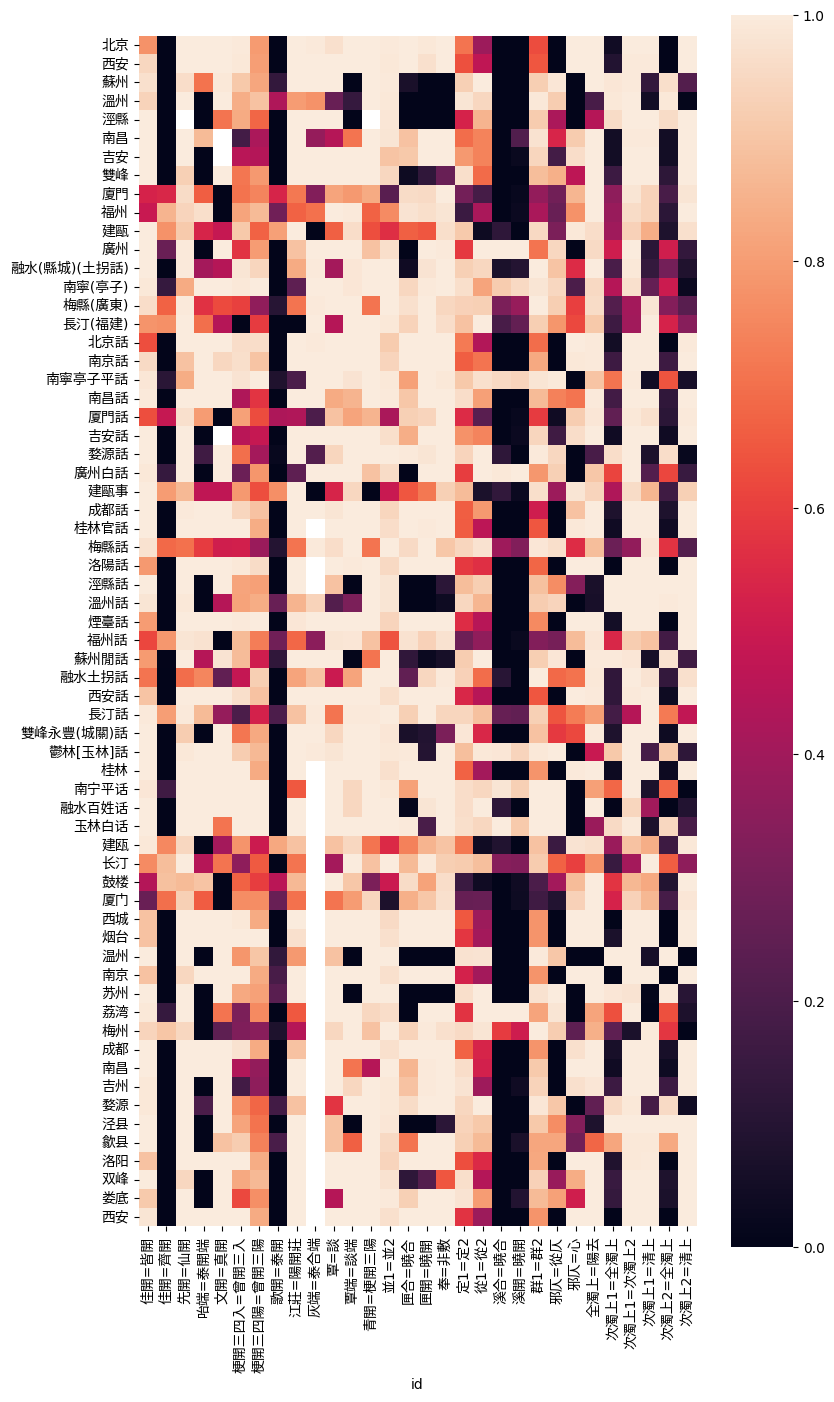

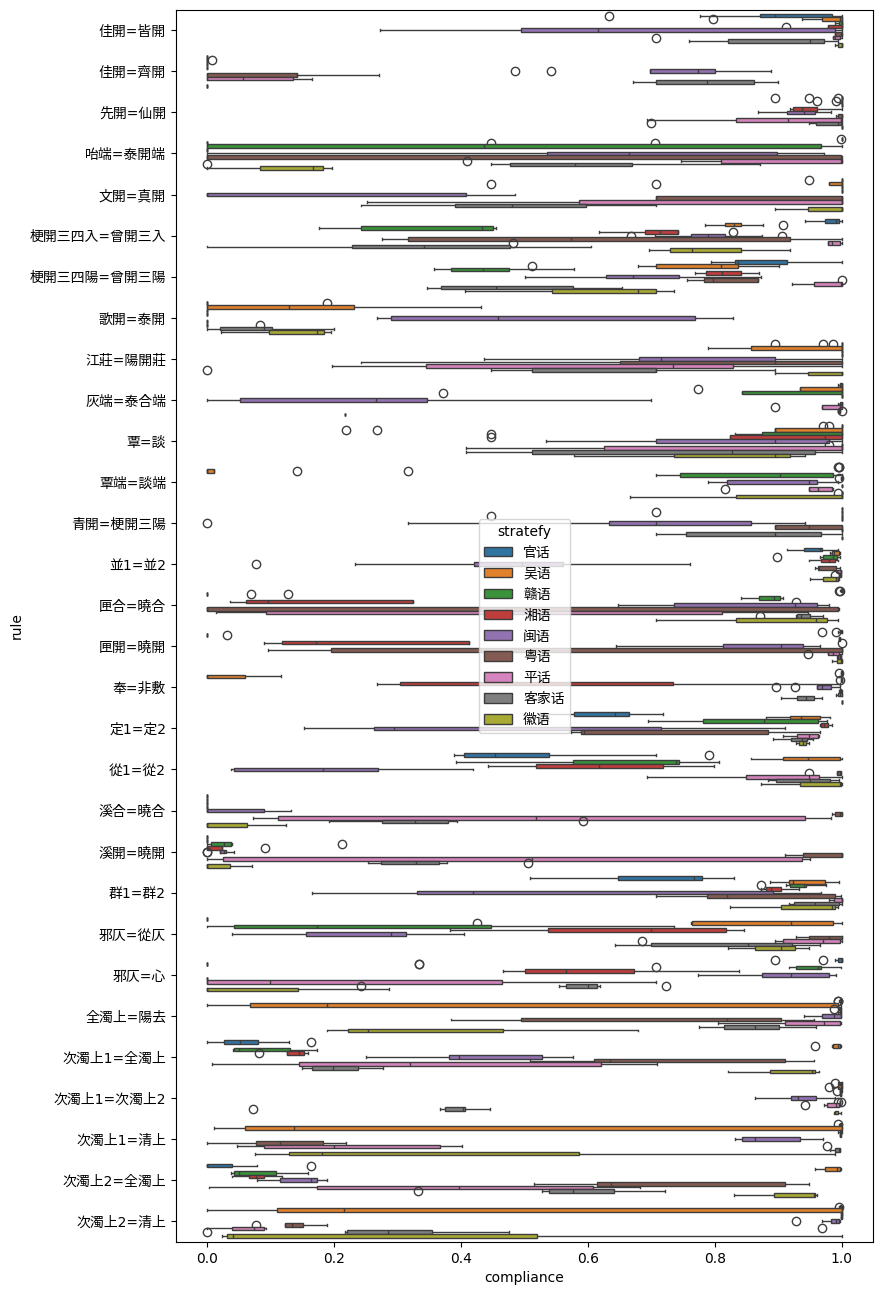

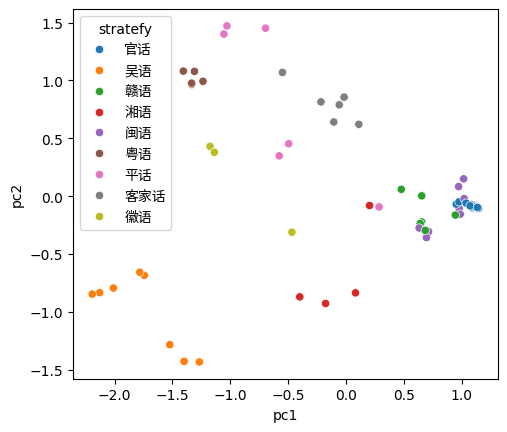

In [7]:
plt.figure(figsize=(9, 16))
sns.heatmap(
    compliances,
    square=True,
    xticklabels=rule_names,
    yticklabels=annotations['name']
)
plt.show()
plt.close()

plt.figure(figsize=(9, 16))
sns.boxplot(
    pd.melt(
        pd.DataFrame(compliances.values, index=compliances.index, columns=rule_names) \
            .assign(stratefy=annotations['stratefy']),
        'stratefy',
        var_name='rule',
        value_name='compliance'
    ),
    x='compliance',
    y='rule',
    hue='stratefy'
)
plt.show()
plt.close()

pc = make_pipeline(KNNImputer(), PCA(2)).fit_transform(compliances)

ax = plt.axes(aspect='equal')
sns.scatterplot(
    annotations.assign(pc1=pc[:, 0], pc2=pc[:, 1]),
    x='pc1',
    y='pc2',
    hue='stratefy',
    ax=ax
)
plt.show()
plt.close()

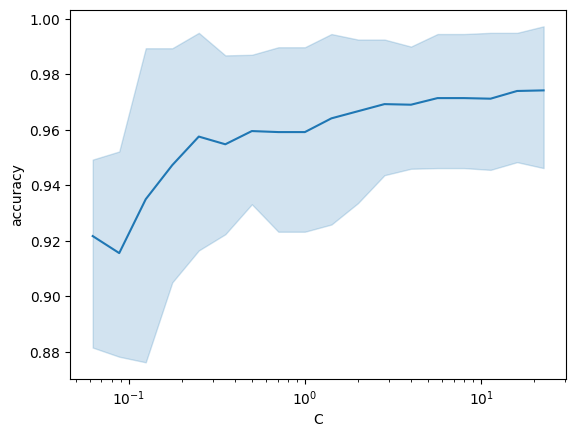

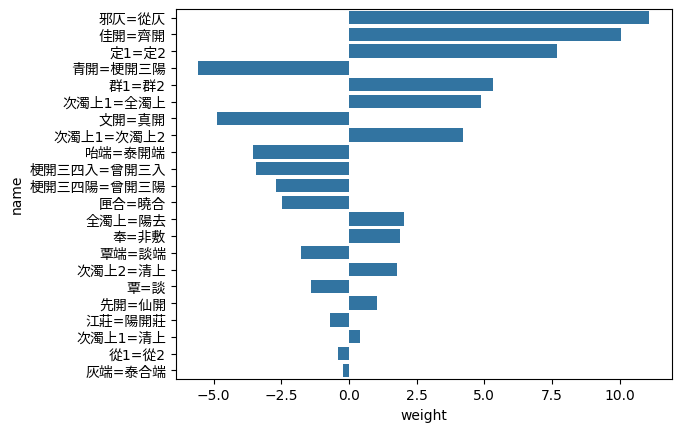

In [8]:
clf = joblib.load(os.path.join(sincomp_root, 'models', 'dialect_classifier.bz2'))

plt.plot()
sns.lineplot(
    pd.melt(
        pd.DataFrame(next(iter(clf.steps[-1][1].scores_.values())).T).assign(C=clf.steps[-1][1].Cs_),
        'C',
        value_name='accuracy'
    ),
    x='C',
    y='accuracy'
)
plt.xscale('log')
plt.show()
plt.close()

w = clf.steps[-1][1].coef_
features = pd.DataFrame({
    'name': rules.loc[(f.split('__')[-1] for f in clf.steps[0][1].get_feature_names_out()), 'name'],
    'weight': w[0],
    'importance': np.std(np.concatenate([np.zeros_like(w), w], axis=0), axis=0)
})

plt.plot()
sns.barplot(
    features[features['importance'] > 0].sort_values('importance', ascending=False),
    x='weight',
    y='name'
)
plt.show()
plt.close()

In [9]:
test_data['predict1'] = clf.predict(compliances1)
test_data['predict2'] = clf.predict(compliances2)
print((test_data['predict1'] == test_data['predict2']).mean())

0.9266666666666666


In [10]:
data_dir = os.path.join(os.path.sep, 'mnt', 'public', 'data', 'dialect_maps')
data = pd.concat(
    [
        pd.concat(
            [sincomp.datasets.get(d).dialects for d in ['CCR', 'MCPDict', 'zhongguoyuyan']],
            axis=0,
            keys=['CCR', 'MCPDict', 'zhongguoyuyan']
        ),
        pd.read_csv(os.path.join(data_dir, 'compliances.csv'), dtype={'dataset': str, 'did': str}).set_index(['dataset', 'did']),
    ],
    axis=1,
    join='inner'
)
data.loc[:, clf.classes_] = clf.predict_proba(data)

In [11]:
background = rasterio.open(os.path.join(os.path.sep, 'mnt', 'public', 'data', 'natural_earth', 'HYP_50M_SR_W', 'HYP_50M_SR_W.tif'))
land = gpd.read_file(os.path.join(os.path.sep, 'mnt', 'public', 'data', 'natural_earth', 'ne_50m_land', 'ne_50m_land.shp'))

/home/dad/venv/sincomp/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:784: UserWarning: Approximating coordinate system <Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
 with the PlateCarree projection.
  warnings.warn(f'Approximating coordinate system {crs!r} with '
/home/dad/venv/sincomp/lib/python3.11/site-packages/cartopy/mpl/geoaxes.py:784: UserWarning: Approximating coordinate system <Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich
 with the PlateCarree projection.

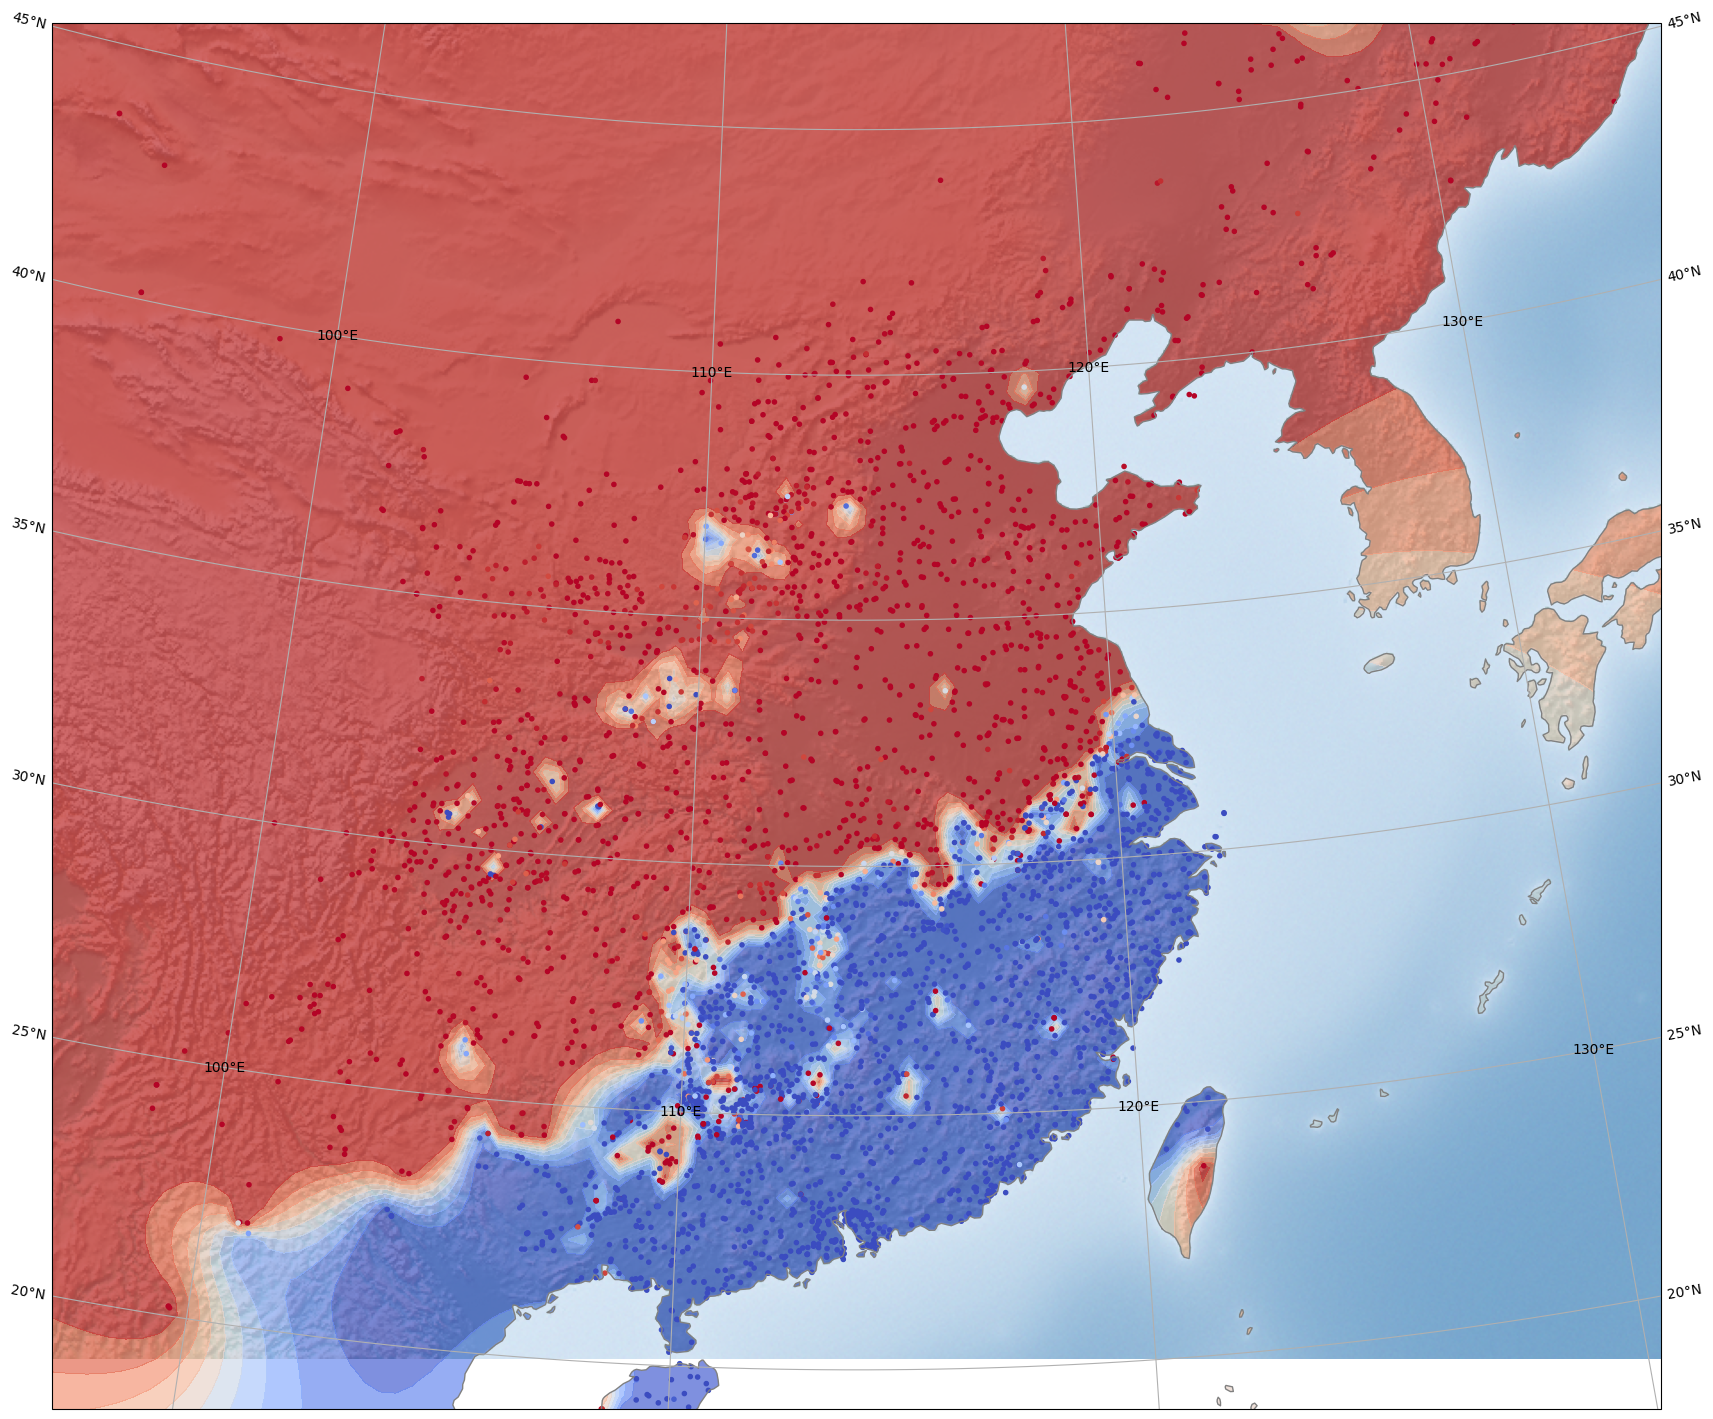

In [12]:
lon0, lat0, lon1, lat1 = background.bounds
extent = sincomp.auxiliary.extent(data.loc[:, 'longitude'], data.loc[:, 'latitude'], coverage=0.99)

plt.figure(figsize=(32, 18))
ax = isogloss(
    data,
    'latitude',
    'longitude',
    '官话',
    proj=ccrs.LambertConformal(0.5 * (extent[0] + extent[1]), 0.5 * (extent[2] + extent[3])),
    background=np.transpose(background.read([1, 2, 3]), (1, 2, 0)),
    background_extent=(lon0, lon1, lat0, lat1),
    geo=land['geometry'],
    extent=extent
)
plt.show()
plt.close()